# OVERVIEW

This notebook serves as an example of how to use the associated src .py files.

### *Imports*

In [13]:
import json
from datetime import datetime, timezone
from pathlib import Path

import requests

PROJECT_ROOT = next(directory for directory in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
                    if (directory / "src" / "crypto_data.py").is_file())

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
API_BASE = "https://revx.revolut.com/api"
SYMBOLS = ("BTC-GBP", "ETH-GBP")
TAKER_FEE_BPS = 9.0
TAKER_FEE_RATE = TAKER_FEE_BPS / 10_000

STUDY_SPEC = {
    "symbols": list(SYMBOLS),
    "data_start": "2019-01-01",
    "development_end_exclusive": "2024-01-01",
    "holdout_end_exclusive": "2026-01-01",
    "signal_lookback_days": 90,
    "decision_frequency": "weekly",
    "taker_fee_bps_per_side": TAKER_FEE_BPS,
    "provisional_round_trip_cost_bps": 25.0,
}

strategy_spec = {
    **STUDY_SPEC,
    "decision_weekday_utc": "Monday",
    "decision_time_utc": "00:00",
    "execution_delay_days": 1,
    "execution_reference": "next_daily_open",
    "target_weight_per_positive_asset": 0.5,
    "rebalance_rule": "weekly_to_target_weights",
}



In [26]:
spec_path = (RAW_DATA_DIR / "coinbase_history_20260915T185923_006583Z" / "strategy_spec_v1.json")
spec_path.write_text(json.dumps(strategy_spec, indent=2), encoding="utf-8")

539

In [14]:
params = {
    "symbols": ",".join(SYMBOLS),
    "region": "UK"
}

response = requests.get(f"{API_BASE}/1.0/public/tickers", params=params, timeout=30)
response.raise_for_status()
payload = response.json()
received_at = datetime.now(timezone.utc)

snapshot = {
    "received_at_utc": received_at.isoformat(),
    "request_url": response.url,
    "payload": payload
}

snapshot_path = RAW_DATA_DIR / (f"tickers_{received_at:%Y%m%dT%H%M%S_%fZ}.json")
with snapshot_path.open("x", encoding="utf-8") as file:
    json.dump(snapshot, file, indent=2)

print(f"Saved: {snapshot_path}")
print(json.dumps(payload, indent=2))

Saved: /Users/oscarlewis/Desktop/python/trading_portfolio/crypto_momentum/data/raw/tickers_20260915T201552_955954Z.json
{
  "data": [
    {
      "symbol": "BTC/GBP",
      "bid": "56353.55",
      "ask": "56359.97",
      "mid": "56356.76",
      "last_price": "56399.17",
      "low_24h": "55566.28",
      "high_24h": "58930",
      "price_change_24h": "-2290.83",
      "volume_24h": "93.74",
      "quote_volume_24h": "5317088.95",
      "region": "UK"
    },
    {
      "symbol": "ETH/GBP",
      "bid": "1785.31",
      "ask": "1785.78",
      "mid": "1785.54",
      "last_price": "1787.88",
      "low_24h": "1748.63",
      "high_24h": "1936.17",
      "price_change_24h": "-117.62",
      "volume_24h": "4065.77",
      "quote_volume_24h": "7358260.58",
      "region": "UK"
    }
  ],
  "metadata": {
    "timestamp": 1789503352871
  }
}


In [15]:
import numpy as np
import pandas as pd

quotes = pd.DataFrame(payload["data"]).set_index("symbol")
expected_symbols = {symbol.replace("-", "/") for symbol in SYMBOLS}

if not quotes.index.is_unique or set(quotes.index) != expected_symbols:
    raise ValueError("Unexpected, missing or duplicate trading pairs.")
if not quotes["region"].eq("UK").all():
    raise ValueError("The response contains non-UK quotes.")

numeric_columns = ["bid", "ask", "last_price", "quote_volume_24h"]
quotes[numeric_columns] = quotes[numeric_columns].apply(pd.to_numeric, errors="raise")

if not np.isfinite(quotes[numeric_columns].to_numpy()).all():
    raise ValueError("Missing or non-finite quote values.")
if ((quotes["bid"] <= 0) | (quotes["ask"] < quotes["bid"]) | (quotes["quote_volume_24h"] < 0)).any():
    raise ValueError("Invalid prices or trading volume.")

quotes["mid_calculated"] = (quotes["bid"] + quotes["ask"]) / 2
quotes["spread_bps"] = (quotes["ask"] - quotes["bid"]) / quotes["mid_calculated"] * 10_000
quotes["approx_round_trip_bps"] = (2 * TAKER_FEE_BPS + quotes["spread_bps"])

display(quotes[[
            "bid",
            "ask",
            "spread_bps",
            "approx_round_trip_bps",
            "quote_volume_24h"
            ]].round(4))

,bid,ask,spread_bps,approx_round_trip_bps,quote_volume_24h
symbol,,,,,
BTC/GBP,56353.55,56359.97,1.1392,19.1392,5317088.95
ETH/GBP,1785.31,1785.78,2.6322,20.6322,7358260.58


In [16]:
import importlib
import sys

source_path = str(PROJECT_ROOT / "src")

if source_path not in sys.path:
    sys.path.insert(0, source_path)

import crypto_data

importlib.reload(crypto_data)

<module 'crypto_data' from '/Users/oscarlewis/Desktop/python/trading_portfolio/crypto_momentum/src/crypto_data.py'>

In [17]:
import time

today_utc = pd.Timestamp.now(tz="UTC").normalize()

sample_starts = {
    "recent": today_utc - pd.Timedelta(days=1),
    "2025": pd.Timestamp("2025-01-03", tz="UTC"),
    "2023": pd.Timestamp("2023-01-03", tz="UTC")
}

candle_samples = {}
coverage_rows = []

for label, start in sample_starts.items():
    end = start + pd.Timedelta(days=1)

    result = result = crypto_data.fetch_candle_sample(symbol="BTC-GBP", start=start, end=end, raw_data_dir=RAW_DATA_DIR)
    candle_samples[label] = result

    candles = pd.DataFrame(result["data"])

    row = {
        "sample": label,
        "requested_start": start,
        "requested_end": end,
        "returned_region": result.get("metadata", {}).get("region"),
        "rows": len(candles)
    }

    if not candles.empty:
        timestamps = pd.to_datetime(candles["start"], unit="ms", utc=True)
        volumes = pd.to_numeric(candles["volume"], errors="raise")

        row.update({
            "first_timestamp": timestamps.min(),
            "last_timestamp": timestamps.max(),
            "duplicate_timestamps": timestamps.duplicated().sum(),
            "zero_volume_rows": volumes.eq(0).sum(),
            "outside_requested_window": ((timestamps < start) | (timestamps >= end)).sum(),
        })

    coverage_rows.append(row)

    #public endpoint requires 1 request per seconds
    time.sleep(1.1)

coverage = pd.DataFrame(coverage_rows).set_index("sample")
display(coverage)

,requested_start,requested_end,returned_region,rows,first_timestamp,last_timestamp,duplicate_timestamps,zero_volume_rows,outside_requested_window
sample,,,,,,,,,
recent,2026-09-14 00:00:00+00:00,2026-09-15 00:00:00+00:00,UK,289,2026-09-14 00:00:00+00:00,2026-09-15 00:00:00+00:00,0.0,27.0,1.0
2025,2025-01-03 00:00:00+00:00,2025-01-04 00:00:00+00:00,UK,0,NaT,NaT,NaN,NaN,NaN
2023,2023-01-03 00:00:00+00:00,2023-01-04 00:00:00+00:00,UK,0,NaT,NaT,NaN,NaN,NaN


In [18]:
importlib.reload(crypto_data)

coinbase_samples = {}
sample_report = []

start = pd.Timestamp("2019-01-01", tz="UTC")
end = pd.Timestamp("2019-02-01", tz="UTC")

for symbol in SYMBOLS:
    rows = crypto_data.fetch_coinbase_daily_sample(
        symbol=symbol,
        start=start,
        end=end,
        raw_data_dir=RAW_DATA_DIR,
    )

    # Coinbase's field order differs from Revolut's.
    candles = pd.DataFrame(
        rows,
        columns=["time", "low", "high", "open", "close", "volume"],
    )

    candles["timestamp"] = pd.to_datetime(
        candles["time"], unit="s", utc=True
    )

    in_window = (
        (candles["timestamp"] >= start)
        & (candles["timestamp"] < end)
    )

    selected = candles.loc[in_window].copy()
    coinbase_samples[symbol] = selected.sort_values("timestamp")

    sample_report.append({
        "symbol": symbol,
        "returned_rows": len(candles),
        "rows_in_window": len(selected),
        "first_timestamp": selected["timestamp"].min(),
        "last_timestamp": selected["timestamp"].max(),
        "duplicate_timestamps": selected["timestamp"].duplicated().sum(),
        "excluded_boundary_or_extra_rows": (~in_window).sum(),
    })

    time.sleep(1.1)

display(pd.DataFrame(sample_report).set_index("symbol"))

,returned_rows,rows_in_window,first_timestamp,last_timestamp,duplicate_timestamps,excluded_boundary_or_extra_rows
symbol,,,,,,
BTC-GBP,32,31,2019-01-01 00:00:00+00:00,2019-01-31 00:00:00+00:00,0,1
ETH-GBP,32,31,2019-01-01 00:00:00+00:00,2019-01-31 00:00:00+00:00,0,1


In [19]:
importlib.reload(crypto_data)


run_started = datetime.now(timezone.utc)
run_dir = RAW_DATA_DIR / (f"coinbase_history_{run_started:%Y%m%dT%H%M%S_%fZ}")
run_dir.mkdir(parents=True, exist_ok=False)

with (run_dir / "study_spec.json").open("x", encoding="utf-8") as file:
    json.dump(STUDY_SPEC, file, indent=2)

price_parts = []
report_parts = []
for symbol in SYMBOLS:
    prices, report = crypto_data.fetch_coinbase_daily_history(
        symbol=symbol,
        start=pd.Timestamp(STUDY_SPEC["data_start"], tz="UTC"),
        end=pd.Timestamp(STUDY_SPEC["holdout_end_exclusive"], tz="UTC"),
        raw_data_dir=run_dir
    )
    price_parts.append(prices)
    report_parts.append(report)

daily_prices = pd.concat(price_parts, ignore_index=True)
download_report = pd.concat(report_parts, ignore_index=True)
download_report.to_csv(run_dir / "download_report.csv", index=False)

print(f"Raw snapshots and study specification saved in: {run_dir}")

display(download_report.groupby("symbol")[[
            "expected_rows",
            "retained_rows",
            "duplicate_timestamps",
            "excluded_rows"
        ]].sum())

BTC-GBP: 2019-01-01 to 2019-09-08 — retained 250 rows
BTC-GBP: 2019-09-08 to 2020-05-15 — retained 250 rows
BTC-GBP: 2020-05-15 to 2021-01-20 — retained 250 rows
BTC-GBP: 2021-01-20 to 2021-09-27 — retained 250 rows
BTC-GBP: 2021-09-27 to 2022-06-04 — retained 250 rows
BTC-GBP: 2022-06-04 to 2023-02-09 — retained 250 rows
BTC-GBP: 2023-02-09 to 2023-10-17 — retained 250 rows
BTC-GBP: 2023-10-17 to 2024-06-23 — retained 250 rows
BTC-GBP: 2024-06-23 to 2025-02-28 — retained 250 rows
BTC-GBP: 2025-02-28 to 2025-11-05 — retained 250 rows
BTC-GBP: 2025-11-05 to 2026-01-01 — retained 57 rows
ETH-GBP: 2019-01-01 to 2019-09-08 — retained 250 rows
ETH-GBP: 2019-09-08 to 2020-05-15 — retained 250 rows
ETH-GBP: 2020-05-15 to 2021-01-20 — retained 250 rows
ETH-GBP: 2021-01-20 to 2021-09-27 — retained 250 rows
ETH-GBP: 2021-09-27 to 2022-06-04 — retained 250 rows
ETH-GBP: 2022-06-04 to 2023-02-09 — retained 250 rows
ETH-GBP: 2023-02-09 to 2023-10-17 — retained 250 rows
ETH-GBP: 2023-10-17 to 2024-0

,expected_rows,retained_rows,duplicate_timestamps,excluded_rows
symbol,,,,
BTC-GBP,2557,2557,0,11
ETH-GBP,2557,2557,0,11


In [20]:
with (run_dir / "strategy_spec_v1.json").open("x", encoding="utf-8") as file:
    json.dump(strategy_spec, file, indent=2)

print(f"Strategy specification saved in: {run_dir}")

Strategy specification saved in: /Users/oscarlewis/Desktop/python/trading_portfolio/crypto_momentum/data/raw/coinbase_history_20260915T201604_090041Z


In [21]:
import crypto_preparation

importlib.reload(crypto_preparation)

normalised_prices, price_audit = (
    crypto_preparation.audit_daily_prices(
        prices=daily_prices,
        symbols=SYMBOLS,
        start=pd.Timestamp(STUDY_SPEC["data_start"], tz="UTC"),
        end=pd.Timestamp(
            STUDY_SPEC["holdout_end_exclusive"], tz="UTC"
        ),
    )
)

display(price_audit.T)

price_audit.to_csv(run_dir / "price_audit.csv")

symbol,BTC-GBP,ETH-GBP
rows,2557,2557
expected_days,2557,2557
missing_days,0,0
invalid_timestamp_rows,0,0
outside_range_rows,0,0
off_midnight_rows,0,0
duplicate_rows,0,0
nonfinite_numeric_rows,0,0
nonpositive_price_rows,0,0
invalid_ohlc_rows,0,0


In [22]:
import crypto_features
importlib.reload(crypto_features)

if not price_audit["passed"].all():
    raise ValueError("Resolve the price audit before building features.")

development_end = pd.Timestamp(STUDY_SPEC["development_end_exclusive"], tz="UTC")
development_prices = normalised_prices.loc[normalised_prices["timestamp"] < development_end].copy()
development_features = crypto_features.add_momentum_features(prices=development_prices, lookback_days=STUDY_SPEC["signal_lookback_days"])
feature_report = development_features.groupby("symbol").agg(price_rows=("timestamp", "size"), available_momentum_rows=("momentum_return", "count"))
feature_report["warmup_rows"] = feature_report["price_rows"] - feature_report["available_momentum_rows"]
display(feature_report)
first_signals = development_features.loc[development_features["momentum_return"].notna()].groupby("symbol", sort=False).head(3)

display(first_signals[["symbol",
            "timestamp",
            "signal_available_at",
            "close",
            "momentum_return",
            "trend_positive"]])

,price_rows,available_momentum_rows,warmup_rows
symbol,,,
BTC-GBP,1826,1736,90
ETH-GBP,1826,1736,90


,symbol,timestamp,signal_available_at,close,momentum_return,trend_positive
90,BTC-GBP,2019-04-01 00:00:00+00:00,2019-04-02 00:00:00+00:00,3175.82,0.050500,True
91,BTC-GBP,2019-04-02 00:00:00+00:00,2019-04-03 00:00:00+00:00,3748.80,0.199616,True
92,BTC-GBP,2019-04-03 00:00:00+00:00,2019-04-04 00:00:00+00:00,3787.00,0.252331,True
1916,ETH-GBP,2019-04-01 00:00:00+00:00,2019-04-02 00:00:00+00:00,108.39,-0.022633,False
1917,ETH-GBP,2019-04-02 00:00:00+00:00,2019-04-03 00:00:00+00:00,125.52,0.011605,True
1918,ETH-GBP,2019-04-03 00:00:00+00:00,2019-04-04 00:00:00+00:00,122.50,0.037169,True


In [ ]:
import crypto_portfolio

importlib.reload(crypto_portfolio)

weekly_targets = crypto_portfolio.build_weekly_targets(
    features=development_features,
    symbols=SYMBOLS,
    execution_end=development_end,
    asset_weight=0.5,
)

display(weekly_targets.head(6))

,decision_at,execution_at,BTC-GBP,ETH-GBP,GBP_cash
0,2019-04-08 00:00:00+00:00,2019-04-09 00:00:00+00:00,0.5,0.5,0.0
1,2019-04-15 00:00:00+00:00,2019-04-16 00:00:00+00:00,0.5,0.5,0.0
2,2019-04-22 00:00:00+00:00,2019-04-23 00:00:00+00:00,0.5,0.5,0.0
3,2019-04-29 00:00:00+00:00,2019-04-30 00:00:00+00:00,0.5,0.5,0.0
4,2019-05-06 00:00:00+00:00,2019-05-07 00:00:00+00:00,0.5,0.5,0.0
5,2019-05-13 00:00:00+00:00,2019-05-14 00:00:00+00:00,0.5,0.5,0.0


In [ ]:
import crypto_backtest

importlib.reload(crypto_backtest)

example_prices = pd.Series({
    "BTC-GBP": 100.0,
    "ETH-GBP": 200.0,
})

example_units = pd.Series({
    "BTC-GBP": 0.0,
    "ETH-GBP": 0.0,
})

example_targets = pd.Series({
    "BTC-GBP": 0.5,
    "ETH-GBP": 0.5,
})

new_units, new_cash, trades = crypto_backtest.rebalance_portfolio(
    units=example_units,
    cash=1_000.0,
    prices=example_prices,
    target_weights=example_targets,
)

equity_after = float((new_units * example_prices).sum() + new_cash)
total_cost = float(trades[["fee", "other_cost"]].to_numpy().sum())

display(trades)

display(pd.Series({
    "equity_before": 1_000.0,
    "equity_after": equity_after,
    "total_cost": total_cost,
    "cash_after": new_cash,
    "accounting_error": equity_after + total_cost - 1_000.0
}))

,reference_price,units_before,units_after,signed_notional,fee,other_cost
symbol,,,,,,
BTC-GBP,100.0,0.0,4.993758,499.37578,0.449438,0.174782
ETH-GBP,200.0,0.0,2.496879,499.37578,0.449438,0.174782


equity_before       1.000000e+03
equity_after        9.987516e+02
total_cost          1.248439e+00
cash_after          4.829470e-15
accounting_error    0.000000e+00
dtype: float64

In [27]:
importlib.reload(crypto_backtest)

other_cost_bps = (
    STUDY_SPEC["provisional_round_trip_cost_bps"] / 2
    - STUDY_SPEC["taker_fee_bps_per_side"]
)

development_ledger, development_trades = (
    crypto_backtest.run_daily_backtest(
        prices=development_prices,
        targets=weekly_targets,
        symbols=SYMBOLS,
        initial_cash=1_000.0,
        fee_bps=STUDY_SPEC["taker_fee_bps_per_side"],
        other_cost_bps=other_cost_bps,
    )
)

display(
    development_ledger[
        [
            "scheduled_rebalance",
            "equity_open",
            "equity_close",
            "cash_gbp",
            "fee",
            "other_cost",
            "traded_notional",
        ]
    ].head(8)
)

print(
    "Maximum rebalance accounting error:",
    development_ledger["rebalance_accounting_error"].abs().max(),
)

display(development_trades.head(4))

,scheduled_rebalance,equity_open,equity_close,cash_gbp,fee,other_cost,traded_notional
candle_start,,,,,,,
2019-04-09 00:00:00+00:00,True,1000.000000,976.057018,4.829470e-15,0.898876,0.349563,998.751561
2019-04-10 00:00:00+00:00,False,976.756727,989.991546,4.829470e-15,0.000000,0.000000,0.000000
2019-04-11 00:00:00+00:00,False,990.027620,934.761221,4.829470e-15,0.000000,0.000000,0.000000
2019-04-12 00:00:00+00:00,False,934.576301,935.643629,4.829470e-15,0.000000,0.000000,0.000000
2019-04-13 00:00:00+00:00,False,935.302958,934.322835,4.829470e-15,0.000000,0.000000,0.000000
2019-04-14 00:00:00+00:00,False,934.657830,951.596582,4.829470e-15,0.000000,0.000000,0.000000
2019-04-15 00:00:00+00:00,False,951.596582,917.569421,4.829470e-15,0.000000,0.000000,0.000000
2019-04-16 00:00:00+00:00,True,913.779333,951.023165,0.000000e+00,0.031185,0.012127,34.649970


Maximum rebalance accounting error: 1.8189894035458565e-12


,symbol,reference_price,units_before,units_after,signed_notional,fee,other_cost,decision_at,execution_at
0,BTC-GBP,4056.75,0.000000,0.123097,499.375780,0.449438,0.174782,2019-04-08 00:00:00+00:00,2019-04-09 00:00:00+00:00
1,ETH-GBP,138.43,0.000000,3.607425,499.375780,0.449438,0.174782,2019-04-08 00:00:00+00:00,2019-04-09 00:00:00+00:00
2,BTC-GBP,3852.35,0.123097,0.118595,-17.346641,0.015612,0.006071,2019-04-15 00:00:00+00:00,2019-04-16 00:00:00+00:00
3,ETH-GBP,121.85,3.607425,3.749430,17.303329,0.015573,0.006056,2019-04-15 00:00:00+00:00,2019-04-16 00:00:00+00:00


In [28]:
importlib.reload(crypto_portfolio)

benchmark_ledgers = {}
benchmark_trades = {}

for mode in ("buy_and_hold", "weekly"):
    benchmark_targets = crypto_portfolio.build_benchmark_targets(
        weekly_targets=weekly_targets,
        symbols=SYMBOLS,
        mode=mode,
    )

    ledger, trades = crypto_backtest.run_daily_backtest(
        prices=development_prices,
        targets=benchmark_targets,
        symbols=SYMBOLS,
        initial_cash=1_000.0,
        fee_bps=STUDY_SPEC["taker_fee_bps_per_side"],
        other_cost_bps=other_cost_bps,
    )

    if not ledger.index.equals(development_ledger.index):
        raise ValueError("Strategy and benchmark dates do not match.")

    benchmark_ledgers[mode] = ledger
    benchmark_trades[mode] = trades

equity_comparison = pd.DataFrame({
    "momentum": development_ledger["equity_close"],
    "buy_and_hold": benchmark_ledgers["buy_and_hold"]["equity_close"],
    "weekly_equal_weight": benchmark_ledgers["weekly"]["equity_close"],
})

display(equity_comparison.head())
display(equity_comparison.tail())

,momentum,buy_and_hold,weekly_equal_weight
candle_start,,,
2019-04-09 00:00:00+00:00,976.057018,976.057018,976.057018
2019-04-10 00:00:00+00:00,989.991546,989.991546,989.991546
2019-04-11 00:00:00+00:00,934.761221,934.761221,934.761221
2019-04-12 00:00:00+00:00,935.643629,935.643629,935.643629
2019-04-13 00:00:00+00:00,934.322835,934.322835,934.322835


,momentum,buy_and_hold,weekly_equal_weight
candle_start,,,
2023-12-27 00:00:00+00:00,4696.714803,10893.686888,12144.558892
2023-12-28 00:00:00+00:00,4638.652718,10765.931796,11994.424501
2023-12-29 00:00:00+00:00,4564.058241,10584.022491,11801.541378
2023-12-30 00:00:00+00:00,4565.048288,10580.852522,11804.101398
2023-12-31 00:00:00+00:00,4569.275873,10581.666798,11815.032902


In [29]:
import crypto_reporting

importlib.reload(crypto_reporting)

development_ledgers = {
    "momentum": development_ledger,
    "buy_and_hold": benchmark_ledgers["buy_and_hold"],
    "weekly_equal_weight": benchmark_ledgers["weekly"],
}

performance_summary = pd.DataFrame({
    name: crypto_reporting.summarise_backtest(ledger)
    for name, ledger in development_ledgers.items()
}).T

display(
    performance_summary.style.format({
        "final_equity_gbp": "£{:,.2f}",
        "total_return": "{:.2%}",
        "cagr": "{:.2%}",
        "annualised_volatility": "{:.2%}",
        "sharpe_zero_cash_rate": "{:.3f}",
        "max_drawdown": "{:.2%}",
        "mean_crypto_weight": "{:.2%}",
        "annualised_one_way_turnover": "{:.2f}",
        "total_cost_gbp": "£{:,.2f}",
    })
)

,final_equity_gbp,total_return,cagr,annualised_volatility,sharpe_zero_cash_rate,max_drawdown,mean_crypto_weight,annualised_one_way_turnover,total_cost_gbp
momentum,"£4,569.28",356.93%,37.87%,57.09%,0.858,-63.40%,60.46%,6.68,£132.81
buy_and_hold,"£10,581.67",958.17%,64.65%,74.33%,1.051,-74.47%,100.00%,0.21,£1.25
weekly_equal_weight,"£11,815.03",1081.50%,68.53%,72.96%,1.089,-73.04%,100.00%,1.47,£51.40


In [31]:
importlib.reload(crypto_portfolio)

constant_mix_targets = crypto_portfolio.build_constant_mix_targets(
    weekly_targets=weekly_targets,
    symbols=SYMBOLS,
    crypto_weight=0.5,
)

constant_mix_ledger, constant_mix_trades = (
    crypto_backtest.run_daily_backtest(
        prices=development_prices,
        targets=constant_mix_targets,
        symbols=SYMBOLS,
        initial_cash=1_000.0,
        fee_bps=STUDY_SPEC["taker_fee_bps_per_side"],
        other_cost_bps=other_cost_bps,
    )
)

if not constant_mix_ledger.index.equals(development_ledger.index):
    raise ValueError("Strategy and benchmark dates do not match.")

development_ledgers["half_crypto_half_cash"] = constant_mix_ledger

performance_summary = pd.DataFrame({
    name: crypto_reporting.summarise_backtest(ledger)
    for name, ledger in development_ledgers.items()
}).T

display(
    performance_summary[
        [
            "cagr",
            "annualised_volatility",
            "sharpe_zero_cash_rate",
            "max_drawdown",
            "mean_crypto_weight",
        ]
    ].style.format({
        "cagr": "{:.2%}",
        "annualised_volatility": "{:.2%}",
        "sharpe_zero_cash_rate": "{:.3f}",
        "max_drawdown": "{:.2%}",
        "mean_crypto_weight": "{:.2%}",
    })
)

,cagr,annualised_volatility,sharpe_zero_cash_rate,max_drawdown,mean_crypto_weight
momentum,37.87%,57.09%,0.858,-63.40%,60.46%
buy_and_hold,64.65%,74.33%,1.051,-74.47%,100.00%
weekly_equal_weight,68.53%,72.96%,1.089,-73.04%,100.00%
half_crypto_half_cash,38.63%,36.25%,1.084,-44.99%,50.12%


In [33]:
import crypto_validation

importlib.reload(crypto_validation)

evaluation_windows = (
    crypto_validation.build_annual_evaluation_windows(
        data_start=pd.Timestamp(STUDY_SPEC["data_start"], tz="UTC"),
        first_test_start=pd.Timestamp("2021-01-01", tz="UTC"),
        evaluation_end=development_end,
    )
)

display(evaluation_windows)

,calibration_start,calibration_end,test_start,test_end
fold,,,,
1,2019-01-01 00:00:00+00:00,2021-01-01 00:00:00+00:00,2021-01-01 00:00:00+00:00,2022-01-01 00:00:00+00:00
2,2019-01-01 00:00:00+00:00,2022-01-01 00:00:00+00:00,2022-01-01 00:00:00+00:00,2023-01-01 00:00:00+00:00
3,2019-01-01 00:00:00+00:00,2023-01-01 00:00:00+00:00,2023-01-01 00:00:00+00:00,2024-01-01 00:00:00+00:00


In [35]:
importlib.reload(crypto_validation)

benchmark_allocations = (
    crypto_validation.calibrate_benchmark_allocations(
        momentum_ledger=development_ledger,
        windows=evaluation_windows,
    )
)

display(
    benchmark_allocations.style.format({
        "crypto_weight": "{:.2%}",
        "BTC_weight": "{:.2%}",
        "ETH_weight": "{:.2%}",
        "cash_weight": "{:.2%}",
    })
)

,first_observation,last_valuation_at,calibration_days,crypto_weight,BTC_weight,ETH_weight,cash_weight
fold,,,,,,,
1,2019-04-09 00:00:00+00:00,2021-01-01 00:00:00+00:00,633,68.50%,34.25%,34.25%,31.50%
2,2019-04-09 00:00:00+00:00,2022-01-01 00:00:00+00:00,998,73.28%,36.64%,36.64%,26.72%
3,2019-04-09 00:00:00+00:00,2023-01-01 00:00:00+00:00,1363,59.00%,29.50%,29.50%,41.00%


In [36]:
importlib.reload(crypto_portfolio)

calibrated_targets = crypto_portfolio.build_calibrated_mix_targets(
    weekly_targets=weekly_targets,
    symbols=SYMBOLS,
    windows=evaluation_windows,
    allocations=benchmark_allocations,
)

calibrated_ledger, calibrated_trades = (
    crypto_backtest.run_daily_backtest(
        prices=development_prices,
        targets=calibrated_targets,
        symbols=SYMBOLS,
        initial_cash=1_000.0,
        fee_bps=STUDY_SPEC["taker_fee_bps_per_side"],
        other_cost_bps=other_cost_bps,
    )
)

if not calibrated_ledger.index.equals(development_ledger.index):
    raise ValueError("Strategy and benchmark dates do not match.")

display(
    calibrated_targets.loc[
        calibrated_targets["calibration_fold"].gt(0)
    ]
    .groupby("calibration_fold", sort=True)
    .head(1)
    [
        [
            "calibration_fold",
            "decision_at",
            "execution_at",
            *SYMBOLS,
            "GBP_cash",
        ]
    ]
)

,calibration_fold,decision_at,execution_at,BTC-GBP,ETH-GBP,GBP_cash
91,1,2021-01-04 00:00:00+00:00,2021-01-05 00:00:00+00:00,0.342485,0.342485,0.315030
143,2,2022-01-03 00:00:00+00:00,2022-01-04 00:00:00+00:00,0.366405,0.366405,0.267189
195,3,2023-01-02 00:00:00+00:00,2023-01-03 00:00:00+00:00,0.295010,0.295010,0.409980


In [37]:
importlib.reload(crypto_reporting)

evaluation_ledgers = {
    **development_ledgers,
    "calibrated_crypto_cash": calibrated_ledger
}
annual_rows = []
for fold, window in evaluation_windows.iterrows():
    for name, ledger in evaluation_ledgers.items():
        summary = crypto_reporting.summarise_backtest_period(
            ledger=ledger,
            start=window["test_start"],
            end=window["test_end"]
        )
        annual_rows.append({
            "year": window["test_start"].year,
            "strategy": name,
            **summary.to_dict()
        })

annual_summary = (pd.DataFrame(annual_rows).set_index(["year", "strategy"]))
display(
    annual_summary[["total_return",
            "annualised_volatility",
            "sharpe_zero_cash_rate",
            "max_drawdown",
            "mean_crypto_weight"]].style.format({
        "total_return": "{:.2%}",
        "annualised_volatility": "{:.2%}",
        "sharpe_zero_cash_rate": "{:.3f}",
        "max_drawdown": "{:.2%}",
        "mean_crypto_weight": "{:.2%}",
    }))

In [40]:
import crypto_sweep

importlib.reload(crypto_reporting)
importlib.reload(crypto_sweep)

LOOKBACKS = (1, 3, 7, 14, 21, 30, 60, 90, 120, 180)

sweep_summary, sweep_annual, sweep_runs = (
    crypto_sweep.run_lookback_sweep(
        prices=development_prices,
        symbols=SYMBOLS,
        lookbacks=LOOKBACKS,
        windows=evaluation_windows,
        initial_cash=1_000.0,
        fee_bps=STUDY_SPEC["taker_fee_bps_per_side"],
        other_cost_bps=other_cost_bps,
    )
)

In [41]:
comparison = sweep_summary.copy()
comparison.index = [
    f"momentum_{days}d"
    for days in comparison.index
]
comparison.index.name = "strategy"

for name in ("half_crypto_half_cash", "weekly_equal_weight"):
    comparison.loc[name] = (
        crypto_reporting.summarise_backtest_period(
            ledger=development_ledgers[name],
            start=evaluation_windows["test_start"].min(),
            end=evaluation_windows["test_end"].max(),
        )
    )

display(
    comparison[
        [
            "total_return",
            "cagr",
            "annualised_volatility",
            "sharpe_zero_cash_rate",
            "max_drawdown",
            "mean_crypto_weight",
            "annualised_one_way_turnover",
        ]
    ].style.format({
        "total_return": "{:.2%}",
        "cagr": "{:.2%}",
        "annualised_volatility": "{:.2%}",
        "sharpe_zero_cash_rate": "{:.3f}",
        "max_drawdown": "{:.2%}",
        "mean_crypto_weight": "{:.2%}",
        "annualised_one_way_turnover": "{:.2f}",
    })
)

display(
    sweep_annual["total_return"]
    .unstack("year")
    .style.format("{:.2%}")
)

,total_return,cagr,annualised_volatility,sharpe_zero_cash_rate,max_drawdown,mean_crypto_weight,annualised_one_way_turnover
strategy,,,,,,,
momentum_1d,14.02%,4.47%,44.61%,0.322,-67.24%,49.72%,27.50
momentum_3d,26.96%,8.29%,47.42%,0.407,-62.50%,53.72%,25.19
momentum_7d,31.49%,9.56%,48.63%,0.432,-54.28%,53.10%,27.35
momentum_14d,-7.24%,-2.48%,49.82%,0.202,-64.25%,53.18%,18.78
momentum_21d,119.78%,30.04%,50.62%,0.774,-46.38%,53.77%,14.16
momentum_30d,417.32%,73.01%,48.79%,1.369,-37.66%,51.12%,10.85
momentum_60d,132.12%,32.43%,51.60%,0.803,-54.55%,56.11%,6.91
momentum_90d,87.23%,23.27%,50.92%,0.666,-60.75%,55.81%,6.96
momentum_120d,198.89%,44.08%,52.99%,0.956,-48.27%,53.71%,5.37


year,2021,2022,2023
lookback_days,,,
1,37.37%,-41.27%,41.34%
3,84.32%,-56.57%,58.58%
7,89.48%,-38.12%,12.15%
14,67.45%,-41.83%,-4.78%
21,91.25%,-16.63%,37.85%
30,277.72%,-22.93%,77.71%
60,156.47%,-40.11%,51.13%
90,142.04%,-39.07%,26.97%
120,169.45%,-22.90%,43.87%


In [42]:
importlib.reload(crypto_sweep)

cost_targets = {
    "momentum_30d": sweep_runs[30]["targets"],
    "half_crypto_half_cash": (
        crypto_portfolio.build_constant_mix_targets(
            weekly_targets=weekly_targets,
            symbols=SYMBOLS,
            crypto_weight=0.5,
        )
    ),
    "weekly_equal_weight": (
        crypto_portfolio.build_benchmark_targets(
            weekly_targets=weekly_targets,
            symbols=SYMBOLS,
            mode="weekly",
        )
    ),
}

cost_summary, cost_runs = crypto_sweep.run_cost_sensitivity(
    prices=development_prices,
    targets_by_strategy=cost_targets,
    symbols=SYMBOLS,
    windows=evaluation_windows,
    round_trip_costs=(25.0, 40.0, 60.0),
    initial_cash=1_000.0,
    fee_bps=STUDY_SPEC["taker_fee_bps_per_side"],
)

display(
    cost_summary[
        [
            "total_return",
            "cagr",
            "annualised_volatility",
            "sharpe_zero_cash_rate",
            "max_drawdown",
        ]
    ].style.format({
        "total_return": "{:.2%}",
        "cagr": "{:.2%}",
        "annualised_volatility": "{:.2%}",
        "sharpe_zero_cash_rate": "{:.3f}",
        "max_drawdown": "{:.2%}",
    })
)

In [43]:
importlib.reload(crypto_validation)

lookback_selections, selection_scores = (
    crypto_validation.select_lookbacks_by_past_sharpe(
        sweep_runs=sweep_runs,
        windows=evaluation_windows,
    )
)

display(
    lookback_selections.style.format({
        "lookback_days": "{:.0f}",
        "training_sharpe": "{:.3f}",
        "training_cagr": "{:.2%}",
        "training_turnover": "{:.2f}",
    })
)

display(
    selection_scores["training_sharpe"]
    .unstack("fold")
    .style.format("{:.3f}")
)

,lookback_days,training_start,training_end,training_sharpe,training_cagr,training_turnover,test_start,test_end
fold,,,,,,,,
1,14,2019-07-03 00:00:00+00:00,2021-01-01 00:00:00+00:00,1.896,128.27%,15.32,2021-01-01 00:00:00+00:00,2022-01-01 00:00:00+00:00
2,30,2019-07-03 00:00:00+00:00,2022-01-01 00:00:00+00:00,1.921,156.04%,9.62,2022-01-01 00:00:00+00:00,2023-01-01 00:00:00+00:00
3,30,2019-07-03 00:00:00+00:00,2023-01-01 00:00:00+00:00,1.391,81.70%,10.06,2023-01-01 00:00:00+00:00,2024-01-01 00:00:00+00:00


fold,1,2,3
lookback_days,,,
1,0.982,0.917,0.453
3,1.729,1.542,0.743
7,0.378,0.830,0.404
14,1.896,1.503,0.914
21,1.730,1.512,1.106
30,1.577,1.921,1.391
60,0.568,1.045,0.621
90,0.603,1.017,0.615
120,1.234,1.409,1.047


In [44]:
importlib.reload(crypto_portfolio)

selected_targets = (
    crypto_portfolio.build_selected_momentum_targets(
        weekly_targets=weekly_targets,
        symbols=SYMBOLS,
        sweep_runs=sweep_runs,
        selections=lookback_selections,
    )
)

selected_ledger, selected_trades = (
    crypto_backtest.run_daily_backtest(
        prices=development_prices,
        targets=selected_targets,
        symbols=SYMBOLS,
        initial_cash=1_000.0,
        fee_bps=STUDY_SPEC["taker_fee_bps_per_side"],
        other_cost_bps=(
            STUDY_SPEC["provisional_round_trip_cost_bps"] / 2
            - STUDY_SPEC["taker_fee_bps_per_side"]
        ),
    )
)

In [45]:
selection_ledgers = {
    "annual_selection": selected_ledger,
    "fixed_30d": sweep_runs[30]["ledger"],
    "half_crypto_half_cash": (
        development_ledgers["half_crypto_half_cash"]
    ),
    "weekly_equal_weight": (
        development_ledgers["weekly_equal_weight"]
    ),
}

selection_comparison = pd.DataFrame({
    name: crypto_reporting.summarise_backtest_period(
        ledger=ledger,
        start=evaluation_windows["test_start"].min(),
        end=evaluation_windows["test_end"].max(),
    )
    for name, ledger in selection_ledgers.items()
}).T

display(
    selection_comparison[
        [
            "total_return",
            "cagr",
            "annualised_volatility",
            "sharpe_zero_cash_rate",
            "max_drawdown",
        ]
    ].style.format({
        "total_return": "{:.2%}",
        "cagr": "{:.2%}",
        "annualised_volatility": "{:.2%}",
        "sharpe_zero_cash_rate": "{:.3f}",
        "max_drawdown": "{:.2%}",
    })
)

selected_annual = pd.DataFrame({
    window["test_start"].year: (
        crypto_reporting.summarise_backtest_period(
            ledger=selected_ledger,
            start=window["test_start"],
            end=window["test_end"],
        )
    )
    for _, window in evaluation_windows.iterrows()
}).T

display(
    selected_annual[["total_return", "max_drawdown"]]
    .style.format("{:.2%}")
)

,total_return,cagr,annualised_volatility,sharpe_zero_cash_rate,max_drawdown
annual_selection,106.20%,27.30%,49.16%,0.739,-43.18%
fixed_30d,417.32%,73.01%,48.79%,1.369,-37.66%
half_crypto_half_cash,88.15%,23.47%,34.49%,0.784,-44.99%
weekly_equal_weight,147.21%,35.24%,69.53%,0.784,-73.04%


,total_return,max_drawdown
2021,50.14%,-43.18%
2022,-22.72%,-37.66%
2023,77.71%,-20.31%


In [47]:
HOLDOUT_PROTOCOL = {
    "version": 1,
    "data_snapshot": str(run_dir.resolve()),
    "data_source": "coinbase_exchange",
    "symbols": list(SYMBOLS),
    "holdout_start": "2024-01-01",
    "holdout_end_exclusive": "2026-01-01",

    "primary_strategy": {
        "name": "fixed_30d",
        "lookback_days": 30,
        "signal": "trailing_close_return_strictly_positive",
        "weight_per_positive_asset": 0.5,
        "inactive_allocation": "GBP_cash",
    },

    "primary_benchmark": {
        "name": "half_crypto_half_cash",
        "BTC_weight": 0.25,
        "ETH_weight": 0.25,
        "cash_weight": 0.5,
    },

    "decision_weekday_utc": "Monday",
    "decision_time_utc": "00:00",
    "execution_delay_days": 1,
    "execution_reference": "next_daily_open",
    "rebalance_rule": "weekly_to_target_weights",
    "carry_pre_holdout_holdings": True,
    "cash_interest_rate": 0.0,
    "forced_terminal_liquidation": False,

    "fee_bps_per_side": 9.0,
    "primary_round_trip_cost_bps": 25.0,
    "secondary_round_trip_costs_bps": [40.0, 60.0],

    "primary_statistic": "strategy_sharpe_minus_benchmark_sharpe",
    "sharpe_annualisation_days": 365.25,
    "bootstrap": {
        "method": "paired_circular_block",
        "block_days": 28,
        "sensitivity_block_days": [14, 56],
        "repetitions": 10_000,
        "seed": 20260916,
        "confidence_level": 0.95,
        "interval_method": "percentile",
    },
    "primary_evidence_criterion": (
        "Primary CI lower bound > 0 and strategy net total return > 0"
    ),

    "secondary_comparisons": [
        "annual_past_sharpe_selection",
        "weekly_equal_weight",
    ],
    "annual_selection": {
        "lookbacks": list(LOOKBACKS),
        "training_start": "2019-07-03",
        "training_end": "start_of_each_evaluation_year",
        "training_window": "expanding",
        "selection_metric": "net_sharpe_at_25bp_round_trip",
        "tie_break": "longer_lookback",
    },

    "development_status": (
        "2019-2023 inspected; candidate grid expanded after viewing results"
    ),
    "secondary_results_cannot_replace_primary_test": True,
}

In [49]:
importlib.reload(crypto_validation)

holdout_protocol_path = (
    PROJECT_ROOT / "research" / "holdout_protocol_v1.json"
)

frozen_protocol = crypto_validation.freeze_research_protocol(
    protocol=HOLDOUT_PROTOCOL,
    path=holdout_protocol_path,
)

print("Saved:", holdout_protocol_path)
print("Recorded at:", frozen_protocol["frozen_at_utc"])
print("Protocol hash:", frozen_protocol["protocol_sha256"])

Saved: /Users/oscarlewis/Desktop/python/trading_portfolio/crypto_momentum/research/holdout_protocol_v1.json
Recorded at: 2026-09-15T23:28:09.268356+00:00
Protocol hash: cfea9a20fa884f93151d4877d27881f5080948b880755f859b726278bc171dea


In [50]:
import numpy as np
import crypto_inference

importlib.reload(crypto_inference)

bootstrap_spec = frozen_protocol["protocol"]["bootstrap"]

synthetic_rng = np.random.default_rng(12345)
synthetic_dates = pd.date_range(
    "2010-01-01",
    periods=731,
    tz="UTC",
)

synthetic_returns = pd.Series(
    synthetic_rng.normal(0.0003, 0.02, len(synthetic_dates)),
    index=synthetic_dates,
)

bootstrap_kwargs = {
    "block_days": bootstrap_spec["block_days"],
    "repetitions": bootstrap_spec["repetitions"],
    "seed": bootstrap_spec["seed"],
    "confidence_level": bootstrap_spec["confidence_level"],
    "annualisation_days": (
        frozen_protocol["protocol"]["sharpe_annualisation_days"]
    ),
}

identical_summary, identical_draws = (
    crypto_inference.paired_sharpe_bootstrap(
        strategy_returns=synthetic_returns,
        benchmark_returns=synthetic_returns,
        **bootstrap_kwargs,
    )
)

shifted_summary, shifted_draws = (
    crypto_inference.paired_sharpe_bootstrap(
        strategy_returns=synthetic_returns + 0.0005,
        benchmark_returns=synthetic_returns,
        **bootstrap_kwargs,
    )
)

assert identical_draws.eq(0.0).all()
assert shifted_draws.gt(0.0).all()

display(pd.DataFrame({
    "identical_returns": identical_summary,
    "added_daily_return": shifted_summary,
}).T)

,observations,block_days,repetitions,strategy_sharpe,benchmark_sharpe,sharpe_difference,ci_lower,ci_upper
identical_returns,731.0,28.0,10000.0,0.119150,0.11915,0.000000,0.000000,0.000000
added_daily_return,731.0,28.0,10000.0,0.590461,0.11915,0.471311,0.453457,0.492115


In [51]:
import crypto_holdout

importlib.reload(crypto_holdout)

if not price_audit["passed"].all():
    raise ValueError("Resolve the price audit before evaluation.")

primary_holdout = crypto_holdout.run_primary_holdout(
    prices=normalised_prices,
    protocol_path=holdout_protocol_path,
    prior_ledgers={
        "fixed_30d": sweep_runs[30]["ledger"],
        "half_crypto_half_cash": (
            development_ledgers["half_crypto_half_cash"]
        ),
    },
)

,total_return,cagr,annualised_volatility,sharpe_zero_cash_rate,max_drawdown,mean_crypto_weight
fixed_30d,96.50%,40.15%,33.67%,1.170,-29.78%,48.49%
half_crypto_half_cash,37.59%,17.28%,27.36%,0.719,-27.32%,50.02%


,sharpe_difference,ci_lower,ci_upper
block_days,,,
28.000000,0.451,-0.605,1.374
14.000000,0.451,-0.573,1.413
56.000000,0.451,-0.586,1.365


Frozen primary evidence criterion met: False


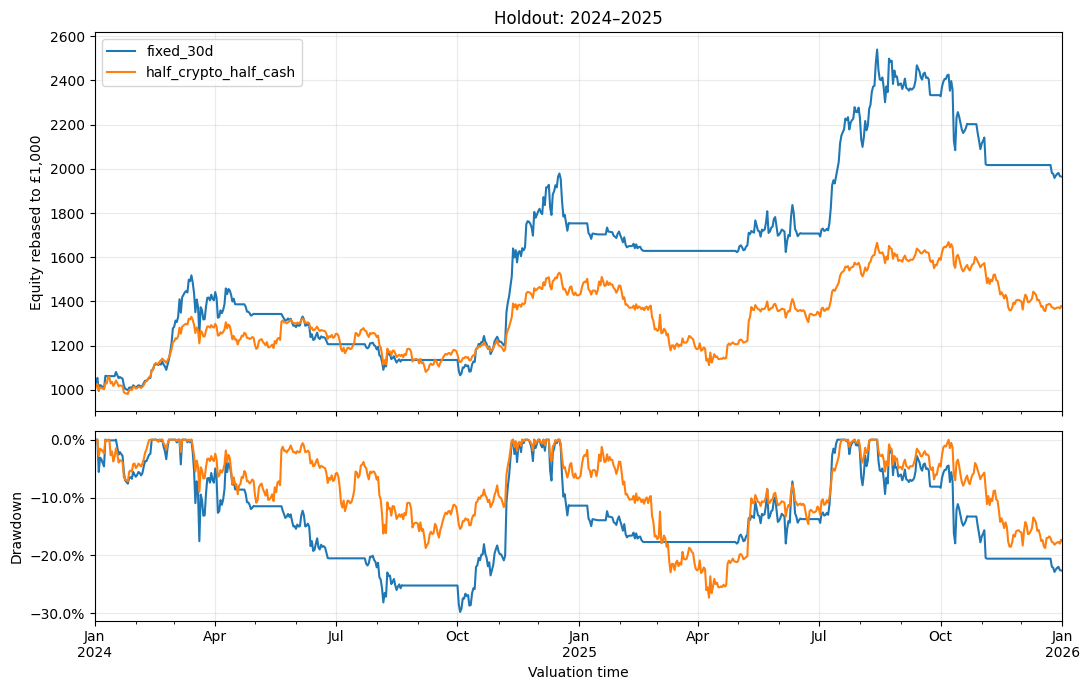

In [52]:
display(
    primary_holdout["performance"][
        [
            "total_return",
            "cagr",
            "annualised_volatility",
            "sharpe_zero_cash_rate",
            "max_drawdown",
            "mean_crypto_weight",
        ]
    ].style.format({
        "total_return": "{:.2%}",
        "cagr": "{:.2%}",
        "annualised_volatility": "{:.2%}",
        "sharpe_zero_cash_rate": "{:.3f}",
        "max_drawdown": "{:.2%}",
        "mean_crypto_weight": "{:.2%}",
    })
)

display(
    primary_holdout["inference"][
        ["sharpe_difference", "ci_lower", "ci_upper"]
    ].style.format("{:.3f}")
)

print(
    "Frozen primary evidence criterion met:",
    primary_holdout["primary_criterion_met"],
)

display(
    crypto_holdout.plot_holdout_equity(
        primary_holdout["equity"]
    )
)

In [56]:
importlib.reload(crypto_holdout)

secondary_holdout = crypto_holdout.run_secondary_holdout(
    prices=normalised_prices,
    primary_result=primary_holdout,
    prior_ledgers={
        "annual_past_sharpe_selection": selected_ledger,
        "weekly_equal_weight": (
            development_ledgers["weekly_equal_weight"]
        ),
    },
    prior_selections=lookback_selections,
)

,lookback_days,training_start,training_end,training_sharpe,test_start,test_end
fold,,,,,,
4,30,2019-07-03 00:00:00+00:00,2024-01-01 00:00:00+00:00,1.441,2024-01-01 00:00:00+00:00,2025-01-01 00:00:00+00:00
5,30,2019-07-03 00:00:00+00:00,2025-01-01 00:00:00+00:00,1.466,2025-01-01 00:00:00+00:00,2026-01-01 00:00:00+00:00


year,2024,2025
strategy,,
annual_past_sharpe_selection,75.35%,12.06%
fixed_30d,75.35%,12.06%
half_crypto_half_cash,42.99%,-3.78%
weekly_equal_weight,85.26%,-12.95%


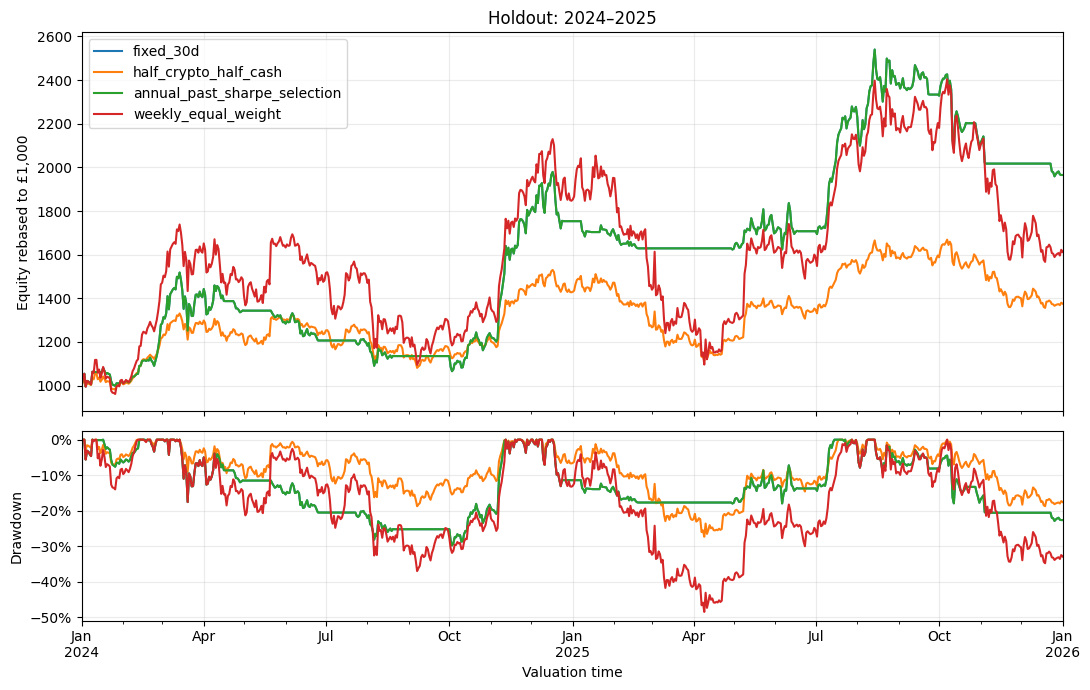

In [57]:
display(
    secondary_holdout["holdout_selections"][
        [
            "lookback_days",
            "training_start",
            "training_end",
            "training_sharpe",
            "test_start",
            "test_end",
        ]
    ].style.format({
        "lookback_days": "{:.0f}",
        "training_sharpe": "{:.3f}",
    })
)

display(
    secondary_holdout["cost_summary"][
        [
            "total_return",
            "cagr",
            "annualised_volatility",
            "sharpe_zero_cash_rate",
            "max_drawdown",
        ]
    ].style.format({
        "total_return": "{:.2%}",
        "cagr": "{:.2%}",
        "annualised_volatility": "{:.2%}",
        "sharpe_zero_cash_rate": "{:.3f}",
        "max_drawdown": "{:.2%}",
    })
)

display(
    secondary_holdout["annual_summary"]["total_return"]
    .unstack("year")
    .style.format("{:.2%}")
)

display(
    crypto_holdout.plot_holdout_equity(
        secondary_holdout["equity"]
    )
)